Num GPUs Available:  1
=== Begin binary classification training with 5-fold CV ===
Training samples after GAN merge: 14053
Binary class distribution in training set: {0: 11798, 1: 2255}
--- Fold 1/5 ---
Fold 1 samples after oversampling: 18876, distribution: [9438 9438]
Fold 1 class_weight: {0: 0.5955710955710956, 1: 3.1158536585365852}
Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.8264 - loss: 1.0252 - val_accuracy: 0.1604 - val_loss: 0.9793 - learning_rate: 1.0000e-04
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9265 - loss: 0.4731 - val_accuracy: 0.1604 - val_loss: 1.1462 - learning_rate: 1.0000e-04
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9243 - loss: 0.4459 - val_accuracy: 0.1604 - val_loss: 1.1626 - learning_rate: 1.0000e-04
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9220 - loss: 0.4329 - val_accuracy: 0.1604 - val_loss: 1.1832 - learning_rate: 1.0000e-04
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━

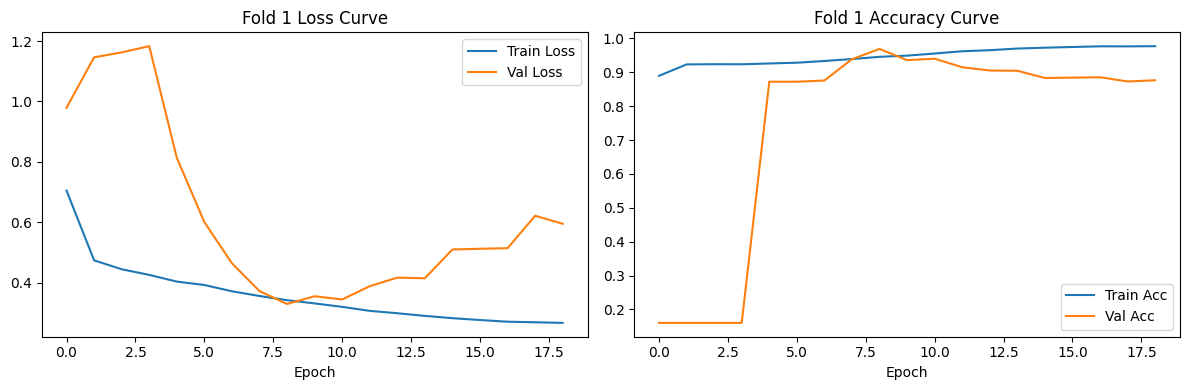

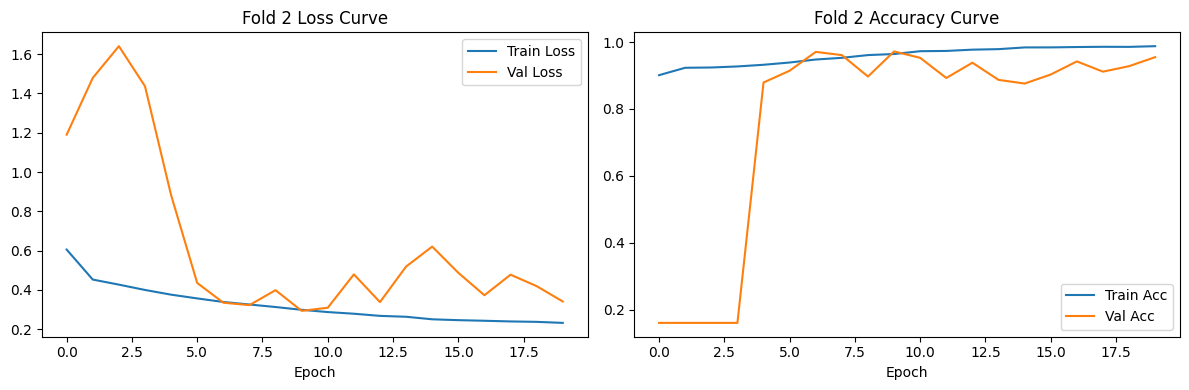

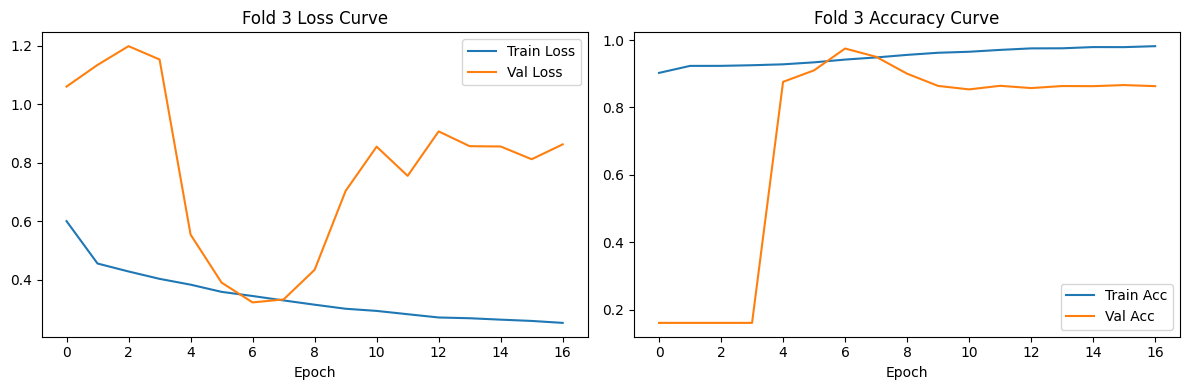

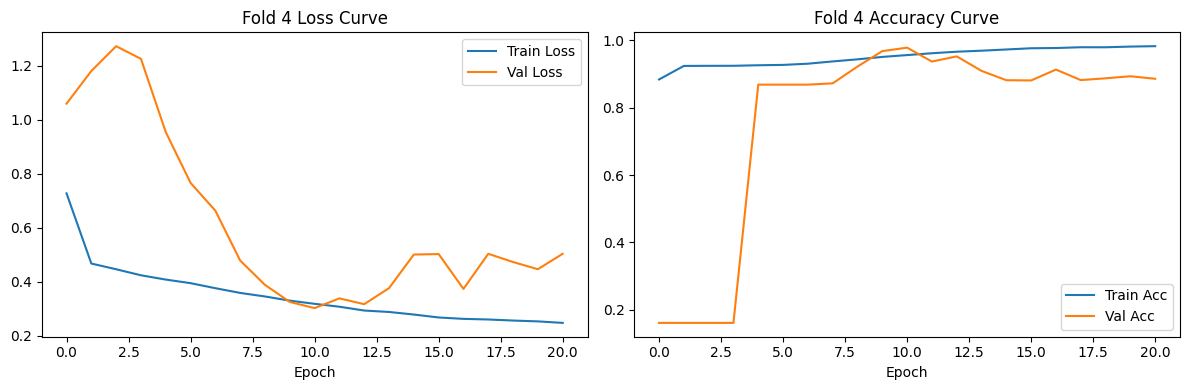

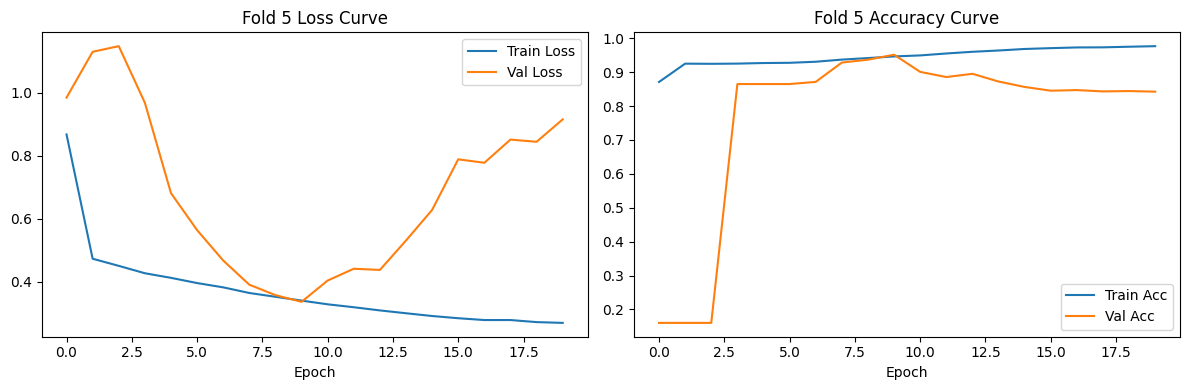

=== Evaluating on Validation set ===
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Fold 1 Validation Accuracy: 0.9691
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Fold 2 Validation Accuracy: 0.9719
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Fold 3 Validation Accuracy: 0.9747
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Fold 4 Validation Accuracy: 0.9786
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Fold 5 Validation Accuracy: 0.9512
=== Overall Validation Accuracy (Ensemble): 0.9691 ===
=== Validation Classification Report ===
              precision    recall  f1-score   support

   normal(0)       0.98      0.98      0.98     11798
 abnormal(1)       0.90      0.91      0.90      2255

    accuracy                           0.97     14053
   macro avg       0.94      0.94      0.94     14053
weighted avg       0.97      0.97      0.97     14053



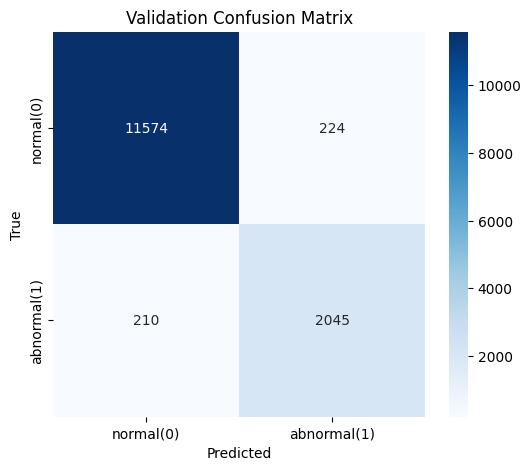

=== Begin testing ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
=== Test Overall Accuracy (Ensemble): 0.5015 ===
=== Test Classification Report ===
              precision    recall  f1-score   support

   normal(0)       0.79      0.22      0.34       593
 abnormal(1)       0.45      0.92      0.60       408

    accuracy                           0.50      1001
   macro avg       0.62      0.57      0.47      1001
weighted avg       0.65      0.50      0.45      1001



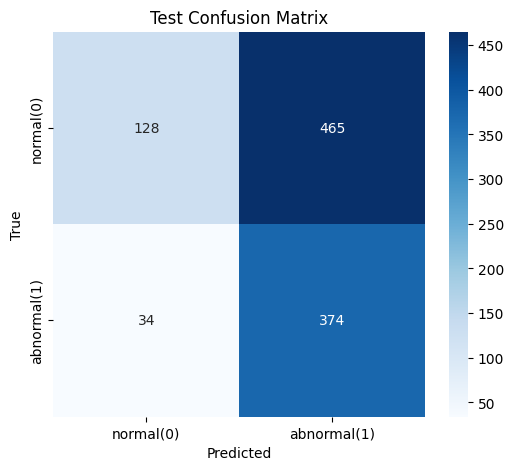

=== Finish testing ===


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings

# ------------------ Configuration Section (Modify as Needed) ------------------
TRAIN_PATH = '../data/train.pickle'   # Path to training pickle file
TEST_PATH  = '../data/test.pickle'    # Path to testing pickle file
GAN_PATH   = '../data/tgan_generated_data.pickle'  # Path to GAN data pickle file, set to None if unused
MODEL_DIR  = 'models_binary'                          # Directory to save trained models
META_SAVE  = 'meta_binary.pkl'                        # File to save normalization metadata
DROP_UNKNOWN_IN_TEST = False  # If True, drop unconvertible labels in test set; if False, map them to abnormal (1)
# ---------------------------------------------------------------

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ==== 1. Load Data ====
def load_data():
    """Load training, GAN, and test datasets"""
    with open(TRAIN_PATH, 'rb') as f:
        train_data = pickle.load(f)
    X_train = np.stack(train_data['sensor_data'])
    y_train = np.array(train_data['label'])
    df_train = pd.DataFrame({'sensor_data': list(X_train), 'label': y_train})

    df_gan = None
    if GAN_PATH is not None:
        with open(GAN_PATH, 'rb') as f:
            gan_data = pickle.load(f)
        X_gan = np.stack([item['sensor_data'] for item in gan_data])
        y_gan = np.array([item['label'] for item in gan_data])
        df_gan = pd.DataFrame({'sensor_data': list(X_gan), 'label': y_gan})

    with open(TEST_PATH, 'rb') as f:
        test_data = pickle.load(f)
    X_test = np.stack(test_data['sensor_data'])
    y_test = np.array(test_data['label'])
    df_test = pd.DataFrame({'sensor_data': list(X_test), 'label': y_test})
    return df_train, df_gan, df_test

# ==== 2. Combine GAN Data ====
def combine_with_gan(df_train, df_gan):
    """Combine GAN data with training data"""
    if df_gan is None:
        return df_train
    return pd.concat([df_train, df_gan], ignore_index=True).reset_index(drop=True)

# ==== 3. Binary Label Mapping ====
def map_binary_label(df, drop_unknown=False):
    """Map labels to binary: 0 (normal), 1 (abnormal)"""
    df = df.copy()
    binary_list = []
    for v in df['label'].values:
        try:
            vi = int(v)
            binary_list.append(0 if vi == 0 else 1)
        except:
            binary_list.append(None if drop_unknown else 1)
    df['binary_temp'] = binary_list
    if drop_unknown:
        mask = df['binary_temp'].notnull()
        if not mask.all():
            warnings.warn(f"Unconvertible labels detected, dropping { (~mask).sum() } records")
        df = df[mask].reset_index(drop=True)
        df['binary_label'] = df['binary_temp'].astype(int)
    else:
        df['binary_label'] = df['binary_temp'].fillna(1).astype(int)
    df = df.drop(columns=['binary_temp'])
    return df.reset_index(drop=True)

# ==== 4. Normalize Sensor Data ====
def normalize_sensor_data(df, means=None, stds=None):
    """Globally standardize sensor data"""
    arr = np.stack(df['sensor_data'].values)
    if means is None or stds is None:
        means = arr.mean(axis=(0,1))
        stds = arr.std(axis=(0,1))
        stds[stds == 0] = 1e-8
    df2 = df.copy()
    normed = (arr - means) / stds
    df2['sensor_data'] = list(normed)
    return df2, means, stds

# ==== 5. Build 2D-CNN Input Sequences ====
def build_2d_sequences(df):
    """Construct input data in (N, H, W, 1) shape"""
    arr = np.stack(df['sensor_data'].values)
    return arr[..., np.newaxis]

# ==== 6. Create 2D-CNN Model ====
def create_2dcnn_binary(sensor_shape):
    """Create a binary classification 2D-CNN model"""
    s_in = tf.keras.Input(shape=sensor_shape, name='sensor_input')
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-3))(s_in)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    y = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-3))(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)
    y = layers.Dropout(0.5)(y)
    out = layers.Dense(2, activation='softmax')(y)

    model = tf.keras.Model(inputs=s_in, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ==== 7. Training Function (5-Fold CV + Ensemble) ====
def train_model_binary(df_train, df_gan=None, n_folds=5):
    """Train model using 5-fold cross-validation"""
    if df_gan is not None:
        df_train = combine_with_gan(df_train, df_gan)
        print(f"Training samples after GAN merge: {len(df_train)}")

    df_train = map_binary_label(df_train, drop_unknown=False)
    unique, counts = np.unique(df_train['binary_label'].values, return_counts=True)
    print(f"Binary class distribution in training set: {dict(zip(unique, counts))}")
    if len(unique) < 2:
        warnings.warn("Only one binary class in training set, training may be ineffective")

    df_train, means, stds = normalize_sensor_data(df_train)
    X_s = build_2d_sequences(df_train)
    y = df_train['binary_label'].values

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    models = []
    histories = []
    val_data_list = []  # 

    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_s, y)):
        print(f"--- Fold {fold+1}/{n_folds} ---")
        Xs_tr, Xs_val = X_s[train_idx], X_s[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # SMOTE oversampling
        Xs_tr_flat = Xs_tr.reshape(Xs_tr.shape[0], -1)
        smote = SMOTE(random_state=42)
        Xs_tr_res_flat, y_tr_res = smote.fit_resample(Xs_tr_flat, y_tr)
        Xs_tr_res = Xs_tr_res_flat.reshape(-1, *Xs_tr.shape[1:])
        print(f"Fold {fold+1} samples after oversampling: {len(Xs_tr_res)}, distribution: {np.bincount(y_tr_res)}")

        # Dynamically compute class weights
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
        class_weight = {0: float(cw[0]), 1: float(cw[1])}
        print(f"Fold {fold+1} class_weight: {class_weight}")

        ytr_one = tf.keras.utils.to_categorical(y_tr_res, num_classes=2)
        yval_one = tf.keras.utils.to_categorical(y_val, num_classes=2)

        model = create_2dcnn_binary(Xs_tr_res.shape[1:])
        cbs = [
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        ]
        history = model.fit(
            Xs_tr_res, ytr_one,
            validation_data=(Xs_val, yval_one),
            epochs=100,
            batch_size=256,
            class_weight=class_weight,
            callbacks=cbs,
            verbose=1
        )
        model.save(os.path.join(MODEL_DIR, f'model_fold_{fold+1}.h5'))
        models.append(model)
        histories.append(history)
        val_data_list.append((Xs_val, y_val))  # 

    return models, histories, means, stds, val_data_list

# ==== 8. Validation Evaluation Function ====
def evaluate_val_binary(models, val_data_list):
    """Evaluate ensemble model on validation set"""
    y_true_all = []
    y_pred_all = []
    for fold, (Xs_val, y_val) in enumerate(val_data_list):
        preds = models[fold].predict(Xs_val)
        y_pred = np.argmax(preds, axis=1)
        y_true_all.extend(y_val)
        y_pred_all.extend(y_pred)
        acc = np.mean(y_pred == y_val)
        print(f"Fold {fold+1} Validation Accuracy: {acc:.4f}")

    overall_acc = np.mean(np.array(y_pred_all) == np.array(y_true_all))
    print(f"=== Overall Validation Accuracy (Ensemble): {overall_acc:.4f} ===")
    target_names = ['normal(0)', 'abnormal(1)']
    print("=== Validation Classification Report ===")
    print(classification_report(y_true_all, y_pred_all, labels=[0,1], target_names=target_names, zero_division=0))
    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Validation Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# ==== 9. Test Evaluation Function (Ensemble) ====
def evaluate_test_binary(models, means, stds, df_test):
    """Evaluate ensemble model on test set"""
    df = map_binary_label(df_test, DROP_UNKNOWN_IN_TEST)
    df, _, _ = normalize_sensor_data(df, means=means, stds=stds)
    Xs = build_2d_sequences(df)
    y_true = df['binary_label'].values

    preds_list = [model.predict(Xs) for model in models]
    preds_avg = np.mean(preds_list, axis=0)
    y_pred = np.argmax(preds_avg, axis=1)

    overall_acc = np.mean(y_pred == y_true)
    print(f"=== Test Overall Accuracy (Ensemble): {overall_acc:.4f} ===")
    target_names = ['normal(0)', 'abnormal(1)']
    print("=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, labels=[0,1], target_names=target_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Test Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# ==== 10. Main Workflow ====
if __name__ == '__main__':
    print("=== Begin binary classification training with 5-fold CV ===")
    df_train, df_gan, df_test = load_data()
    models, histories, means, stds, val_data_list = train_model_binary(df_train, df_gan)

    joblib.dump((means, stds), META_SAVE)
    print(f"Training complete, models saved to {MODEL_DIR}, normalization params saved to {META_SAVE}")

    for fold, history in enumerate(histories, 1):
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title(f'Fold {fold} Loss Curve')
        plt.xlabel('Epoch')
        plt.legend()
        plt.subplot(1,2,2)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title(f'Fold {fold} Accuracy Curve')
        plt.xlabel('Epoch')
        plt.legend()
        plt.tight_layout()
        plt.show()

    print("=== Evaluating on Validation set ===")
    evaluate_val_binary(models, val_data_list)

    print("=== Begin testing ===")
    evaluate_test_binary(models, means, stds, df_test)
    print("=== Finish testing ===")